# Restaurant Orders Analysis

## Project Overview
This project analyzes restaurant order data to uncover customer preferences, sales performance, and revenue insights using Python, Pandas, Matplotlib, and Seaborn.

## Objectives
- Analyze customer ordering behavior.
- Identify top-selling menu items.
- Evaluate category performance.
- Discover revenue drivers.
- Visualize business insights.

### A-loading Data and Libraries

In [79]:
# import Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import seaborn as sns


# set style of visualization
sns.set_style("darkgrid")
sns.set_palette("deep")

In [80]:
# Read Data set 
order = pd.read_csv("order_details.csv")

In [81]:
# see top 5 rows of Data 
order.head()

,order_details_id,order_id,order_date,order_time,item_id
0,1,1,1/1/2023,11:38:36 AM,109.0
1,2,2,1/1/2023,11:57:40 AM,108.0
2,3,2,1/1/2023,11:57:40 AM,124.0
3,4,2,1/1/2023,11:57:40 AM,117.0
4,5,2,1/1/2023,11:57:40 AM,129.0


In [82]:
# see number of rows and columns 
rows ,columns = order.shape
f"number of rows is {rows}, and number of columns is {columns}"

'number of rows is 12234, and number of columns is 5'

In [83]:
# check missing values 
order.isna().sum()

order_details_id      0
order_id              0
order_date            0
order_time            0
item_id             137
dtype: int64

In [84]:
# see quick info of Data
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12234 entries, 0 to 12233
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_details_id  12234 non-null  int64  
 1   order_id          12234 non-null  int64  
 2   order_date        12234 non-null  object 
 3   order_time        12234 non-null  object 
 4   item_id           12097 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 478.0+ KB


In [85]:
# check of duplicated rows 
order. duplicated().any()

np.False_

In [86]:
# see unique values of each column
unique_values = order.nunique().reset_index()
unique_values.rename(columns={"index" :"column neam",0 : "# unique values"} ,inplace = True )
unique_values 

,column neam,# unique values
0,order_details_id,12234
1,order_id,5370
2,order_date,90
3,order_time,5010
4,item_id,32


In [87]:
#see quick info of data
order.describe(include=object)

,order_date,order_time
count,12234,12234
unique,90,5010
top,2/1/2023,1:13:33 PM
freq,188,16


In [88]:
# see rows  that have null values 
order[order["item_id"].isna()]

,order_details_id,order_id,order_date,order_time,item_id
121,122,50,1/1/2023,6:41:01 PM,NaN
297,298,125,1/2/2023,8:31:06 PM,NaN
357,358,147,1/3/2023,2:32:51 PM,NaN
386,387,161,1/3/2023,4:43:46 PM,NaN
469,470,200,1/3/2023,10:24:05 PM,NaN
...,...,...,...,...,...
11716,11717,5149,3/28/2023,2:48:50 PM,NaN
11903,11904,5225,3/29/2023,5:40:52 PM,NaN
11906,11907,5226,3/29/2023,5:43:56 PM,NaN
12021,12022,5281,3/30/2023,4:56:04 PM,NaN


In [89]:
order_id=order.loc[order["item_id"].isna(), "order_id"].tolist()

In [90]:
for id in order_id [:5]:
    count= order[order["order_id"]==id].shape[0]
    print(f"order id {id}----->{count}")

order id 50----->1
order id 125----->1
order id 147----->1
order id 161----->3
order id 200----->1


In [91]:
order[order["order_id"]==740]

,order_details_id,order_id,order_date,order_time,item_id
1654,1655,740,1/13/2023,12:29:51 PM,102.0
1655,1656,740,1/13/2023,12:29:51 PM,104.0
1656,1657,740,1/13/2023,12:29:51 PM,124.0
1657,1658,740,1/13/2023,12:29:51 PM,125.0
1658,1659,740,1/13/2023,12:29:51 PM,110.0
1659,1660,740,1/13/2023,12:29:51 PM,117.0
1660,1661,740,1/13/2023,12:29:51 PM,111.0
1661,1662,740,1/13/2023,12:29:51 PM,119.0
1662,1663,740,1/13/2023,12:29:51 PM,120.0
1663,1664,740,1/13/2023,12:29:51 PM,131.0


In [92]:
#red data set 
menu= pd.read_csv("menu_items.csv")

In [93]:
menu.head()

,menu_item_id,item_name,category,price
0,101,Hamburger,American,12.95
1,102,Cheeseburger,American,13.95
2,103,Hot Dog,American,9.00
3,104,Veggie Burger,American,10.50
4,105,Mac & Cheese,American,7.00


In [94]:
data=order.merge(menu, left_on = "item_id" , right_on= "menu_item_id")


In [95]:
#remove column"menu_item_id"
data.drop(columns = "menu_item_id",inplace =True )

In [96]:
#see data after merged
data.head()


,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price
0,1,1,1/1/2023,11:38:36 AM,109.0,Korean Beef Bowl,Asian,17.95
1,2,2,1/1/2023,11:57:40 AM,108.0,Tofu Pad Thai,Asian,14.50
2,3,2,1/1/2023,11:57:40 AM,124.0,Spaghetti,Italian,14.50
3,4,2,1/1/2023,11:57:40 AM,117.0,Chicken Burrito,Mexican,12.95
4,5,2,1/1/2023,11:57:40 AM,129.0,Mushroom Ravioli,Italian,15.50


In [97]:
data.sample(2)

,order_details_id,order_id,order_date,order_time,item_id,item_name,category,price
2747,2782,1231,1/21/2023,4:45:04 PM,122.0,Chips & Salsa,Mexican,7.0
132,134,56,1/1/2023,7:07:00 PM,108.0,Tofu Pad Thai,Asian,14.5


##### B- Business Question 1
Which menu items are ordered the most?

### 1- Top 10 Most Ordered Items (Horizontal Bar Chart)

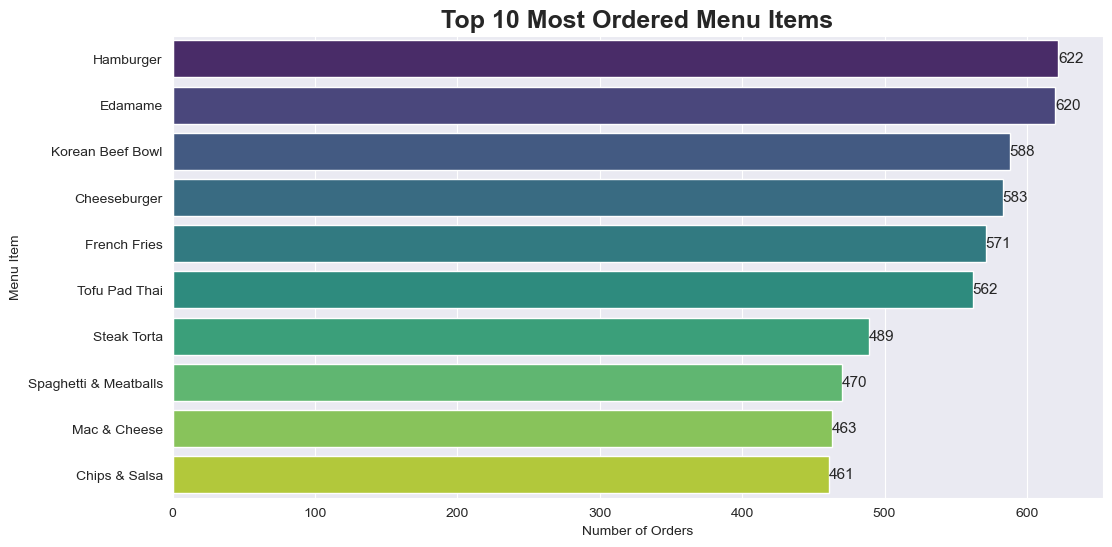

In [74]:
top_items = data["item_name"].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_items.values,
    y=top_items.index,
    palette="viridis"
)

plt.title("Top 10 Most Ordered Menu Items", fontsize=18, fontweight="bold")
plt.xlabel("Number of Orders")
plt.ylabel("Menu Item")

for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.show()

### 2- Orders by Category (Bar Chart)

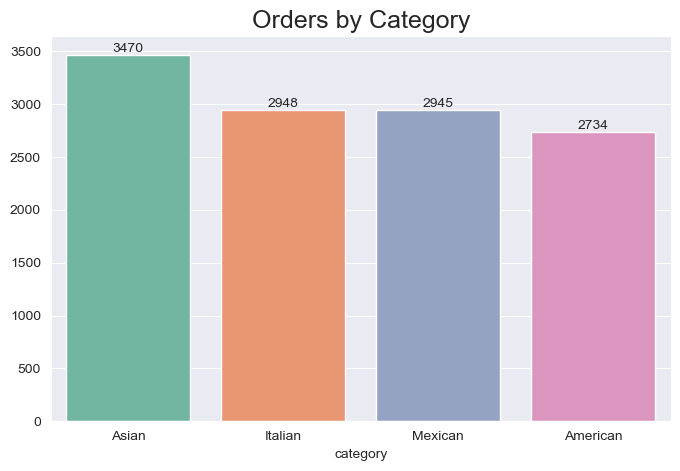

In [73]:
category = data["category"].value_counts()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=category.index,
    y=category.values,
    palette="Set2"
)

plt.title("Orders by Category",fontsize=18)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 3- Category Share (Pie Chart)

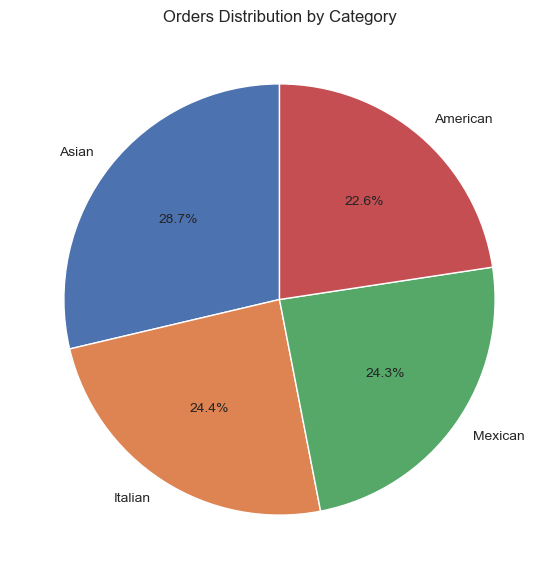

In [60]:
category = data["category"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    category,
    labels=category.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Orders Distribution by Category")
plt.show()

### 4- Revenue by Category (Bar Chart)

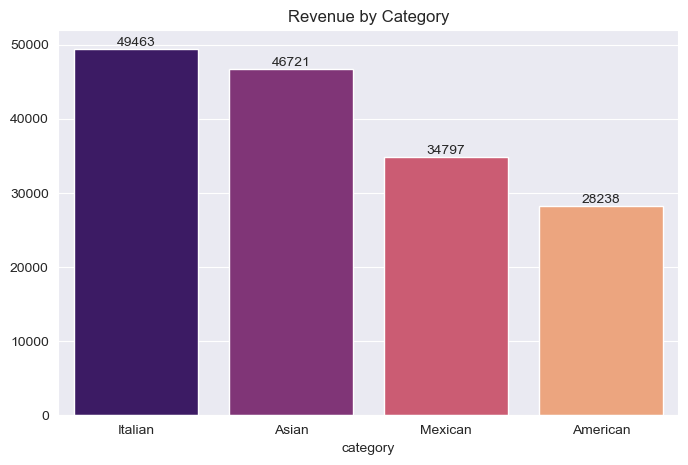

In [75]:
sales = data.groupby("category")["price"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=sales.index,
    y=sales.values,
    palette="magma"
)

plt.title("Revenue by Category")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

### 5- Top 10 Revenue Items (Horizontal Bar Chart)

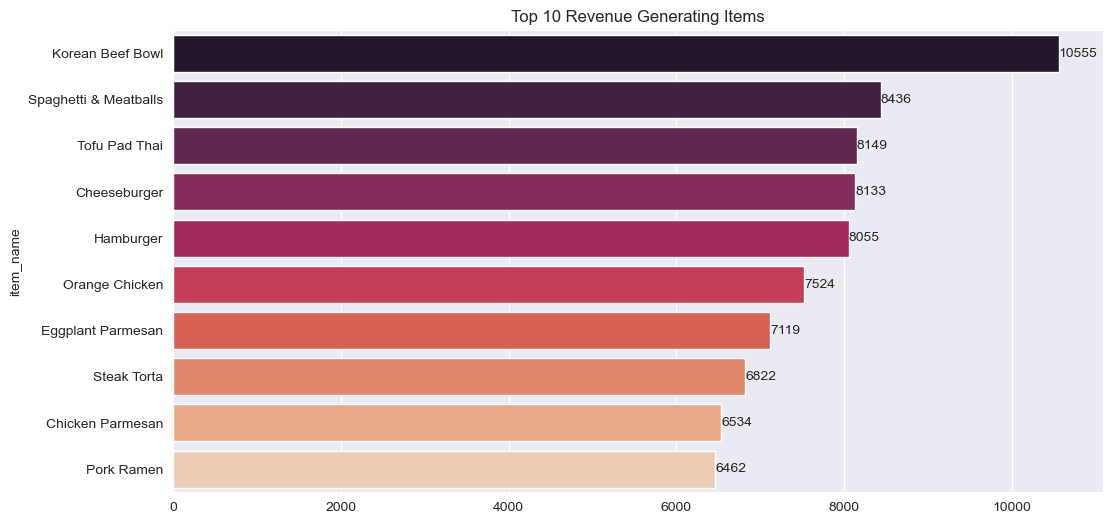

In [76]:
top_sales = data.groupby("item_name")["price"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_sales.values,
    y=top_sales.index,
    palette="rocket"
)

plt.title("Top 10 Revenue Generating Items")

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

### 6- Price Distribution (Histogram)

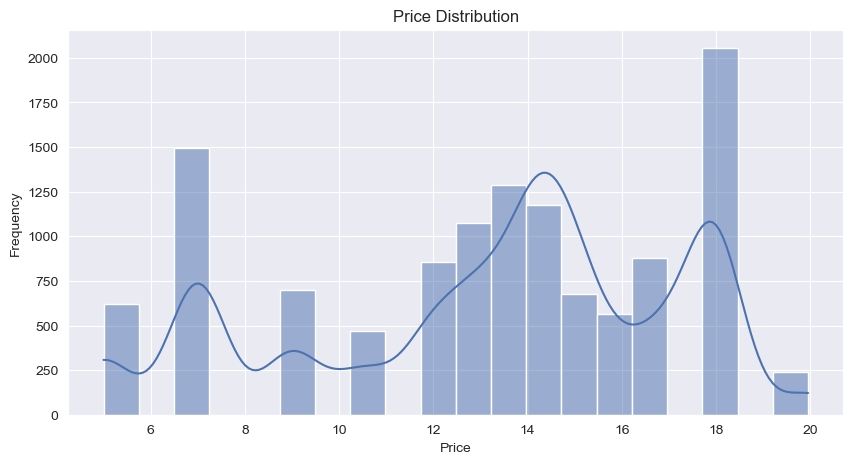

In [63]:
plt.figure(figsize=(10,5))

sns.histplot(
    data["price"],
    bins=20,
    kde=True
)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

### 7- Price vs Orders (Scatter Plot)

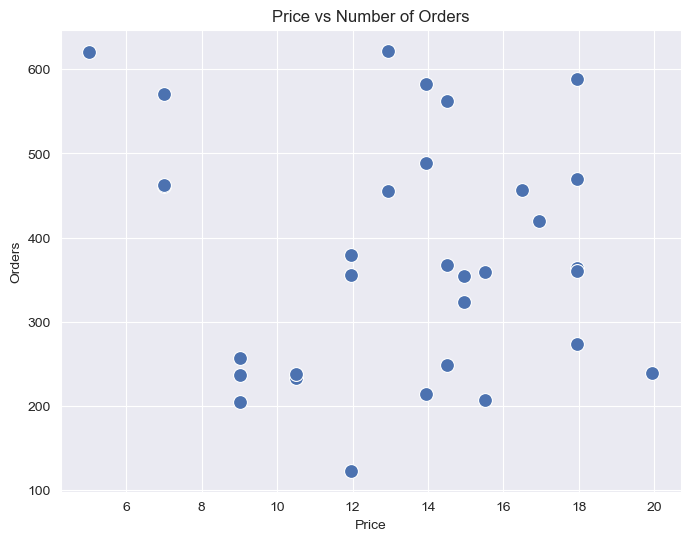

In [64]:
item = data.groupby("item_name").agg(
    Orders=("item_id","count"),
    Price=("price","mean")
).reset_index()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=item,
    x="Price",
    y="Orders",
    s=100
)

plt.title("Price vs Number of Orders")

plt.show()

### 8- Average Price by Category (Bar Chart)

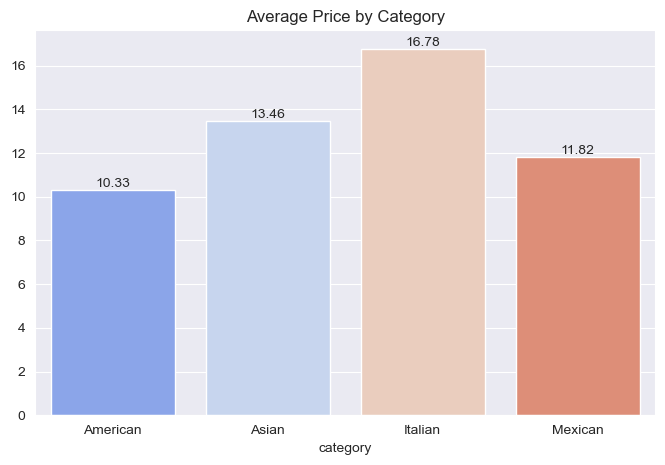

In [77]:
avg_price = data.groupby("category")["price"].mean()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette="coolwarm"
)

plt.title("Average Price by Category")

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

### 9- Box Plot of Prices by Category

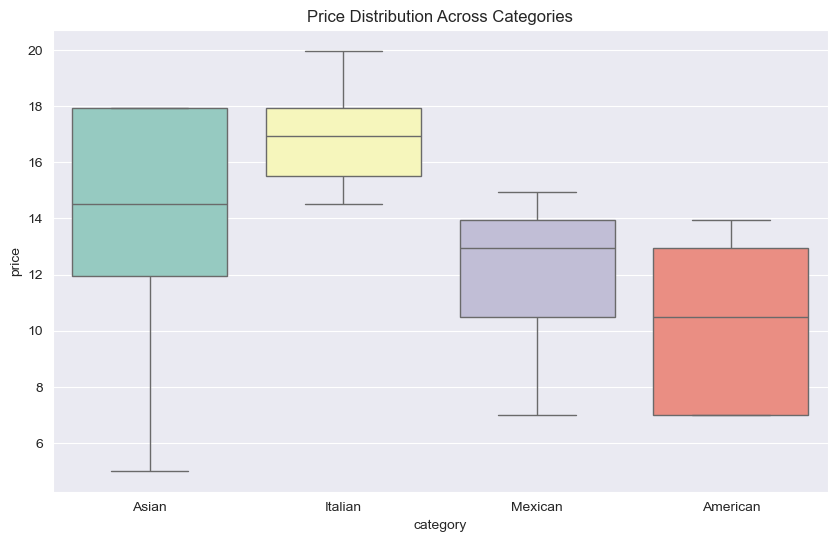

In [78]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=data,
    x="category",
    y="price",
    palette="Set3"
)

plt.title("Price Distribution Across Categories")

plt.show()

### 10- Heatmap (Correlation)

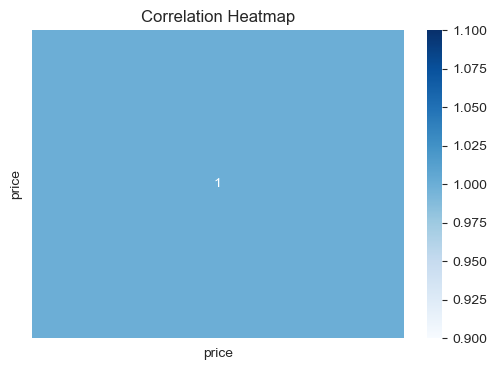

In [67]:
plt.figure(figsize=(6,4))

sns.heatmap(
    data[["price"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

# Conclusion

This analysis shows that:

- Asian cuisine receives the highest number of orders.
- Italian cuisine generates the highest revenue.
- Premium-priced products can still achieve high demand.
- Menu optimization should focus on the best-performing items.

# Recommendations

- Promote high-revenue products.
- Bundle low-selling items with best sellers.
- Increase marketing for Italian dishes.
- Review pricing strategy for underperforming products.